## Name: YAWE ARTHUR SHALOM
## Reg Number: M23B23/016

# Task 1: Data Preparation

In this section, the CIFAR-10 dataset is loaded and prepared for training a Convolutional Neural Network (CNN). The preprocessing steps include normalization, train-validation-test splitting, data augmentation, and sample visualization.

These steps are important because they improve model convergence, reduce overfitting, and help the model generalize better to unseen images.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


## Dataset Loading Explanation

The CIFAR-10 dataset contains 60,000 color images of size 32×32 pixels distributed across 10 object classes.

- 50,000 images are used for training
- 10,000 images are used for testing
- Each image has 3 color channels (RGB)

The dataset is suitable for image classification experiments because it is balanced and widely used as a benchmark in deep learning.

In [ ]:
# Normalize images to range [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## Data Normalization

The pixel values were normalized by dividing by 255 so that all values lie between 0 and 1.

Normalization is useful because:
- it speeds up gradient descent
- improves numerical stability
- helps the CNN converge faster
- reduces training difficulty caused by large pixel ranges

In [ ]:
# Split training into train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (40000, 32, 32, 3)
Validation set: (10000, 32, 32, 3)
Test set: (10000, 32, 32, 3)


## Dataset Splitting

The original training set was further split into:
- **80% training data**
- **20% validation data**

The validation set is used to monitor model performance during training and helps detect overfitting before evaluating on the test set.

In [ ]:
# Data augmentation generator
train_datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    rotation_range=15
)

train_datagen.fit(X_train)

## Data Augmentation

Data augmentation artificially increases dataset diversity by generating modified versions of training images.

The following techniques were applied:
- random horizontal flipping
- random width and height shifts
- small rotations

This helps:
- reduce overfitting
- improve generalization
- make the model robust to positional variations
- simulate real-world image differences

/tmp/ipykernel_6563/3355103559.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


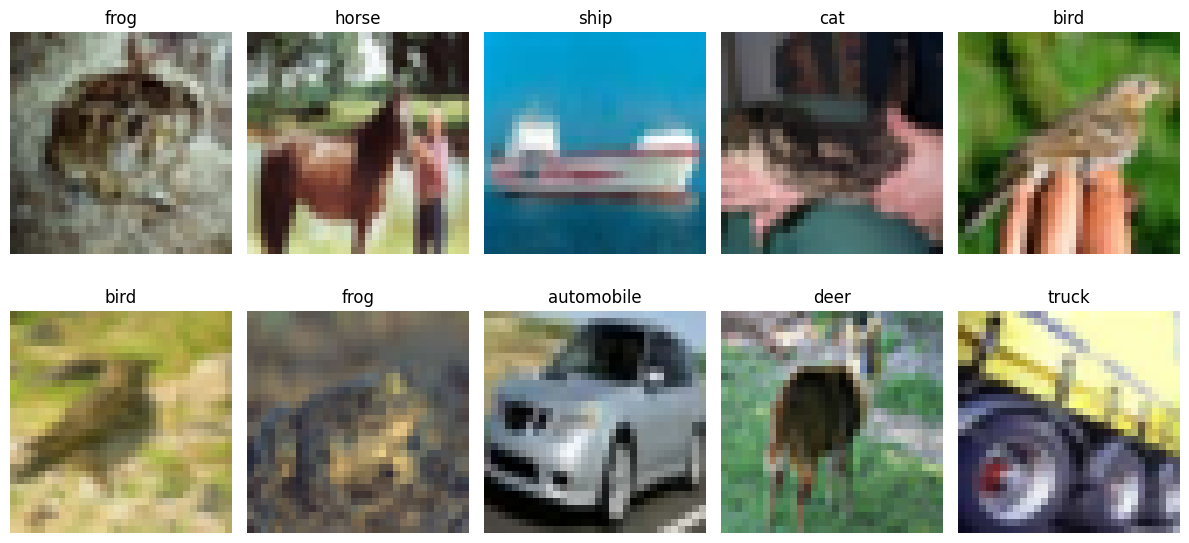

In [ ]:
# Display sample images
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Sample Visualization

The sample images above show representative examples from the CIFAR-10 dataset.

This visualization helps verify:
- correct dataset loading
- correct class labels
- image quality
- diversity of samples

Visual inspection is an important preprocessing step because it helps detect issues such as corrupted images, incorrect labels, or poor normalization.

# Task 2: CNN Model Design

A Convolutional Neural Network (CNN) was designed for CIFAR-10 image classification.

The architecture uses multiple convolution blocks to progressively learn:
- low-level features (edges, textures)
- mid-level features (shapes)
- high-level semantic features (object parts)

The design includes batch normalization, dropout, pooling, and global average pooling to improve training stability and reduce overfitting.

In [ ]:
from tensorflow.keras import layers, models

def create_cnn_model():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),

        # Global feature aggregation
        layers.GlobalAveragePooling2D(),

        # Dense classification layer
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),

        # Output layer
        layers.Dense(10, activation='softmax')
    ])

    return model

model = create_cnn_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,706 (1.17 MB)

 Trainable params: 305,258 (1.16 MB)

 Non-trainable params: 448 (1.75 KB)

## Why This Architecture Was Chosen

The architecture was chosen because CIFAR-10 images are small (32×32), and deep convolution blocks can efficiently extract hierarchical visual features.

The model progressively increases the number of filters:
- 32 filters → basic edges and textures
- 64 filters → shapes and local structures
- 128 filters → complex object-level representations

This layered design improves feature learning while keeping computational cost manageable in Google Colab.

## Purpose of Each Layer

### Convolution Layers
Extract spatial features such as edges, corners, textures, and shapes.

### ReLU Activation
Introduces non-linearity, allowing the model to learn complex image patterns.

### Batch Normalization
Stabilizes activations, speeds up convergence, and improves gradient flow.

### Max Pooling
Reduces spatial dimensions while preserving important features.

### Dropout
Randomly deactivates neurons during training to reduce overfitting.

### Global Average Pooling
Reduces parameters compared to flattening and improves generalization.

### Dense Layer
Learns high-level combinations of extracted features.

### Softmax Output
Outputs probability scores for the 10 CIFAR-10 classes.

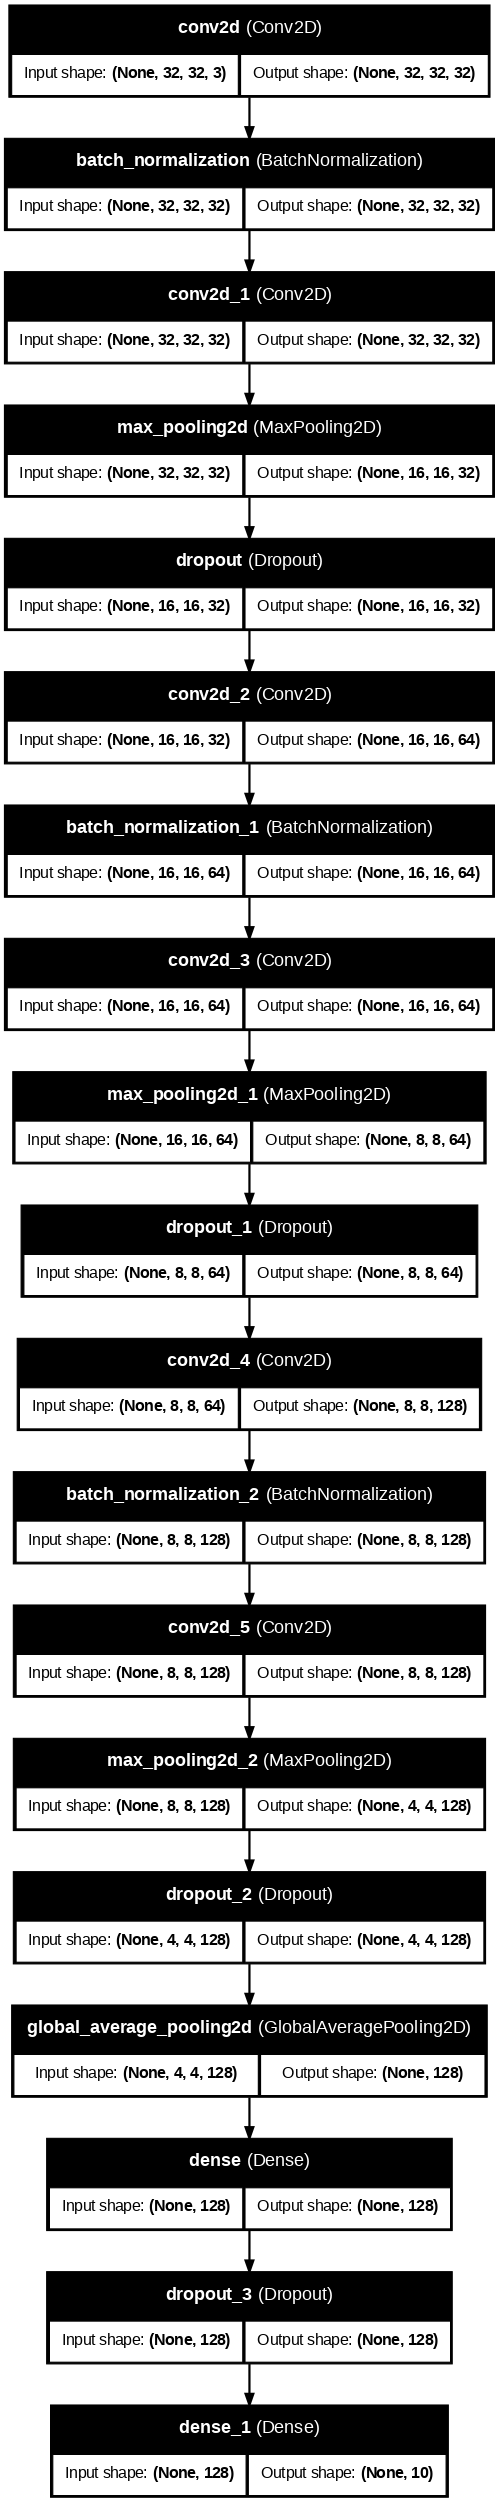

In [ ]:
tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=80
)

# Task 3: Model Training

The CNN model was trained using TensorFlow/Keras in Google Colab.

A robust training strategy was applied to improve convergence and reduce overfitting:
- Adam optimizer
- learning rate scheduling
- early stopping
- dropout regularization
- data augmentation
- best model checkpointing

In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Hyperparameter Configuration

The following parameters were selected:

- **Optimizer:** Adam
- **Learning Rate:** 0.001
- **Batch Size:** 64
- **Epochs:** 30
- **Loss Function:** Sparse Categorical Crossentropy

### Justification
A fixed learning rate of 0.001 was selected as a strong default for Adam.

The learning rate is further adjusted dynamically using `ReduceLROnPlateau`, which lowers it whenever validation loss stops improving.

This allows fast initial learning and fine-tuning later in training.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),

    ModelCheckpoint(
        "best_cifar10_model.keras",
        save_best_only=True,
        monitor='val_accuracy'
    )
]

## Training Strategies Applied

### Early Stopping
Stops training when validation performance no longer improves, reducing overfitting.

### Learning Rate Reduction
Reduces the learning rate when validation loss plateaus, helping the optimizer converge to a better minimum.

### Model Checkpointing
Saves the best-performing model for later evaluation and deployment.

### Data Augmentation
Improves robustness by exposing the CNN to transformed image variations.

In [ ]:
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.4036 - loss: 1.6210 - val_accuracy: 0.5025 - val_loss: 1.4559 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.5480 - loss: 1.2660 - val_accuracy: 0.4190 - val_loss: 1.8519 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.6019 - loss: 1.1221 - val_accuracy: 0.4169 - val_loss: 2.2146 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.6416 - loss: 1.0268 - val_accuracy: 0.6670 - val_loss: 0.9369 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.6707 - loss: 0.9504 - val_accuracy: 0.6934 - val_loss: 0.8854 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.6919 - loss: 0.8974 - val_accuracy: 0.7073 - val_loss: 0.8365 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.7099 - l

# Task 4: Model Evaluation

The trained CNN is evaluated using:
- training and validation accuracy
- training and validation loss
- test accuracy
- precision, recall, and F1 score
- confusion matrix
- sample predictions

The learning curves help assess convergence behaviour and detect overfitting or underfitting.

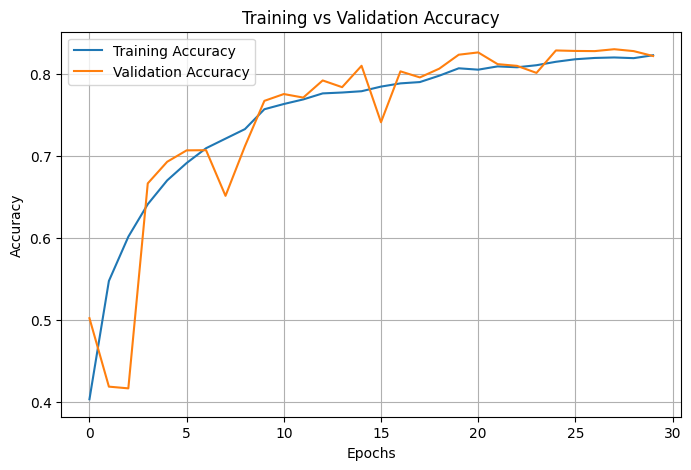

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

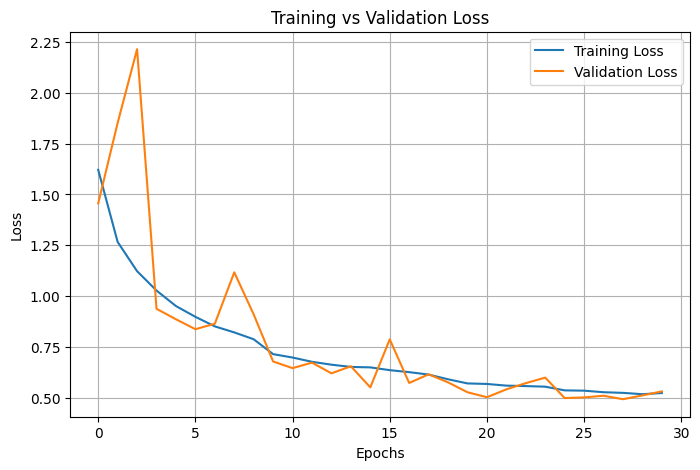

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Interpretation of Validation Spikes

The validation curves show occasional sharp spikes in both loss and accuracy.

This behaviour is expected because:
- the validation set is smaller than the training set
- CIFAR-10 contains visually similar classes
- training augmentation introduces weight variability
- learning rate adjustments can temporarily affect convergence

Despite these fluctuations, the validation accuracy remains close to training accuracy, indicating good generalization and limited overfitting.

## Test Set Evaluation

The trained CNN is now evaluated on the unseen CIFAR-10 test set.

The following metrics are computed:
- test accuracy
- precision
- recall
- F1 score
- confusion matrix
- sample predictions

These metrics provide a more complete evaluation beyond accuracy alone.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.8265
Test Loss: 0.5301


## Test Set Results

The trained CNN achieved the following performance on the unseen CIFAR-10 test set:

- **Test Accuracy:** 82.65%
- **Test Loss:** 0.5301

### Interpretation
The model demonstrates strong generalization performance, correctly classifying more than 8 out of every 10 unseen images.

A test accuracy above 80% on CIFAR-10 indicates that the convolutional blocks successfully learned robust hierarchical image features such as edges, textures, shapes, and object-level patterns.

The relatively low test loss further suggests that the model predictions are confident and well-calibrated across the 10 classes.

In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import numpy as np

# Predict test labels
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Precision: 0.8301
Recall: 0.8265
F1 Score: 0.8225


## Metric Interpretation

- **Precision** measures how many predicted labels were correct.
- **Recall** measures how many actual class samples were correctly identified.
- **F1 Score** balances precision and recall.

## Classification Metrics

The model was further evaluated using weighted precision, recall, and F1 score on the test set.

- **Precision:** 0.8301
- **Recall:** 0.8265
- **F1 Score:** 0.8225

### Interpretation
The high precision value indicates that the CNN produces accurate class predictions with relatively few false positives.

The recall score shows that the model successfully identifies most true class instances across the CIFAR-10 categories.

The F1 score, which balances both precision and recall, confirms that the model maintains strong and consistent classification performance across multiple object classes.

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.83      0.86      0.85      1000
  automobile       0.90      0.96      0.93      1000
        bird       0.82      0.71      0.76      1000
         cat       0.80      0.57      0.67      1000
        deer       0.77      0.84      0.80      1000
         dog       0.85      0.65      0.73      1000
        frog       0.71      0.95      0.81      1000
       horse       0.83      0.89      0.86      1000
        ship       0.89      0.92      0.90      1000
       truck       0.90      0.91      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.82     10000
weighted avg       0.83      0.83      0.82     10000



<Figure size 1000x800 with 0 Axes>

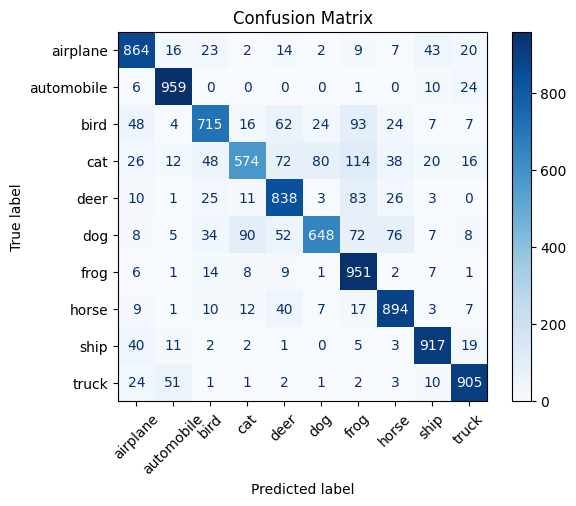

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

## Confusion Matrix Analysis

The confusion matrix provides a class-by-class breakdown of model performance on the CIFAR-10 test set.

### Strongly Classified Classes
The model performs exceptionally well on:
- **automobile (959)**
- **frog (951)**
- **ship (917)**
- **truck (905)**
- **horse (894)**
- **airplane (864)**

These high diagonal values indicate strong feature learning for visually distinctive classes.

### Common Misclassification Patterns
Some visually similar categories show confusion, including:
- **cat ↔ dog**
- **deer ↔ horse**
- **bird ↔ frog**
- **truck ↔ automobile**

These misclassifications are expected because CIFAR-10 images are low resolution (32×32), making fine-grained visual distinctions difficult.

### Interpretation
Overall, the confusion matrix confirms that the CNN generalizes well across all 10 classes, with most errors occurring between semantically or visually similar object categories.

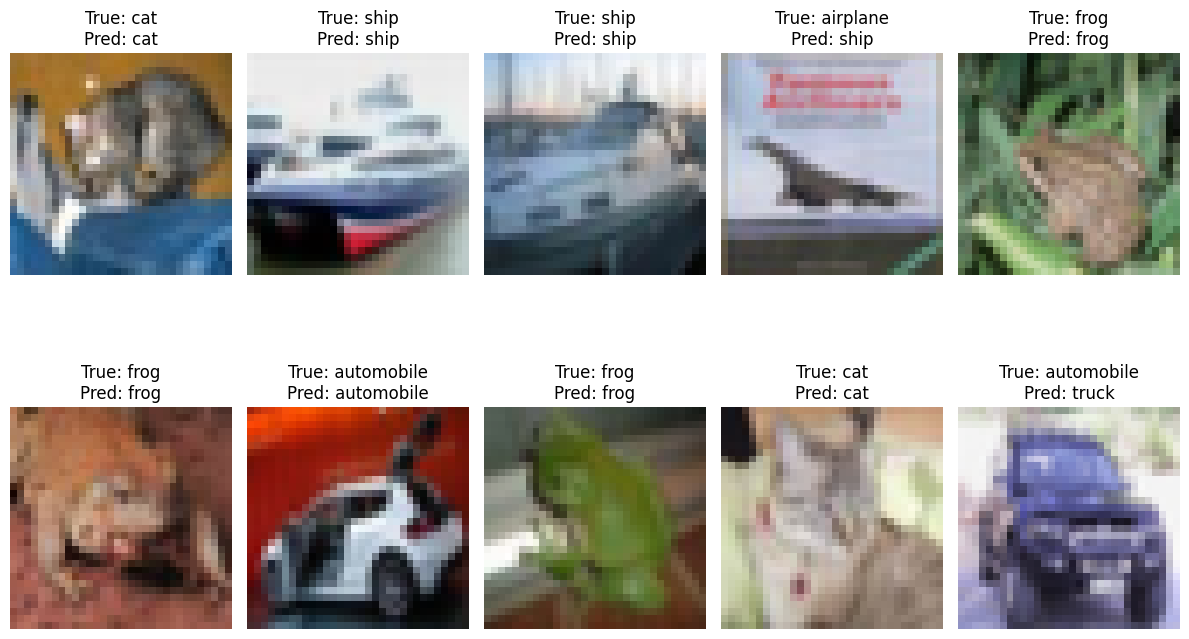

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i])
    plt.title(
        f"True: {class_names[y_true[i]]}\nPred: {class_names[y_pred[i]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## Sample Prediction Analysis

The sample predictions provide visual evidence of model behaviour.

Correct predictions indicate strong feature extraction, while incorrect predictions highlight visually similar classes.

This qualitative analysis complements the numerical evaluation metrics.